# Lunch prediction notebook

# **Machine Learning project : Intellicanteen**

Our team :
- **OUADAH Lina Selma (G5)**
- **BELAMRI Chakib (G1)**
- **HENNI Mohammed Yassine (G1)**
- **MEZIGHECHE Malak Yasmine (G10)**


#  IntelliCanteen— Lunch Visitor Count Prediction
### Pipeline: Imports → EDA → Log Transform → Feature Eng → Distribution Check → Train/Val/Test Split → Baseline + Overfitting Check → Optuna → Final Diagnosis

##  0 — Imports

In [ ]:
!pip install xgboost lightgbm optuna -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
!pip install xgboost lightgbm optuna -q
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from itertools import combinations
from scipy import stats

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

print(' All imports done')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 13.7 MB/s eta 0:00:00
 All imports done


##  1 — Load Data

In [ ]:
LOAD_THREW_GOOGLE_COLAB = True

In [ ]:
import pandas as pd
import io

if LOAD_THREW_GOOGLE_COLAB :
    from google.colab import files

    # 1. This will create a 'Choose Files' button
    uploaded = files.upload()

    # 2. Get the filename from the upload dictionary
    # (It works even if the file is named .xlsx but is actually a csv)
    file_name = list(uploaded.keys())[0]

    # 3. Read it as a CSV
    df = pd.read_csv(io.BytesIO(uploaded[file_name]))



Saving lunch_data.xlsx to lunch_data.xlsx


In [ ]:
if not LOAD_THREW_GOOGLE_COLAB:
    path = "lunch.csv"
    df = pd.read_csv(path)

print(f'Loaded — Shape: {df.shape}')
df.head(5)

Loaded — Shape: (222544, 56)


,create_date,resto_name,dou_code,new_count,meal_type_id,meal,year,month,day,is_Monday,...,ramadan_x_weekend,is_month_start,is_month_end,rolling_mean_day_4w,visitors_lag_21,diff_lag_1_2,diff_lag_1_7,lag_7_ratio,ewma_3,ewma_diff
0,2024-01-08,ANON_0035909ef97c,301,3,2,"سلاطة خضراء,مرقة لوبيا,كاشير,حلوى قشطية",2024,1,8,1,...,0,0,0,620.802281,620.802281,620.802281,0.000000,1.000000,620.802281,620.802281
1,2024-01-09,ANON_0035909ef97c,301,127,2,"سلاطة متنوعة,سباقيتي,سمك,فواكه",2024,1,9,0,...,0,0,0,3.000000,620.802281,620.802281,-617.802281,0.004832,3.000000,0.000000
2,2024-01-10,ANON_0035909ef97c,301,287,2,"سلاطة خضراء,مرق الحمص,تونة,عصير",2024,1,10,0,...,0,0,0,65.000000,620.802281,124.000000,-493.802281,0.204574,85.666667,11.809524
3,2024-01-11,ANON_0035909ef97c,301,267,2,"سلاطة متنوعة,جلبانة,باتي,ياغورت",2024,1,11,0,...,0,0,0,139.000000,620.802281,160.000000,-333.802281,0.462305,200.714286,34.687259
4,2024-01-14,ANON_0035909ef97c,301,399,2,"سلطة متنوعة,مقرونة,تونة,عصير",2024,1,14,0,...,0,0,0,171.000000,620.802281,-20.000000,-353.802281,0.430089,236.066667,33.112381


##  2 — Quick EDA

In [ ]:
# Reassign the dataframe to keep only years that are NOT 2023
df = df[df['year'] != 2023]

In [ ]:
print('--- Column Data Types ---')
print(df.dtypes)
print()
missing = df.isnull().sum()
missing = missing[missing > 0]
if len(missing) == 0:
    print(' No missing values!')
else:
    print('☁ Missing:', missing)
print()
print('\n--- Target Variable (new_count) — Descriptive Statistics ---')
print('This shows the range, spread, and central tendency of lunch visitor counts.')
print(df['new_count'].describe())
print(f'Zero-count days  : {(df["new_count"] == 0).sum()}    (days with no recorded visitors — may indicate closures or data gaps)')
print(f'Negative-count days: {(df["new_count"] < 0).sum()}    (should be 0; any negative value signals a data quality issue)')

--- Column Data Types ---
create_date                      object
resto_name                       object
dou_code                          int64
new_count                         int64
meal_type_id                      int64
meal                             object
year                              int64
month                             int64
day                               int64
is_Monday                         int64
is_Tuesday                        int64
is_Wednesday                      int64
is_Thursday                       int64
is_Friday                         int64
is_Saturday                       int64
is_Sunday                         int64
meal_w2v_1                      float64
meal_w2v_2                      float64
meal_w2v_3                      float64
meal_w2v_4                      float64
meal_w2v_5                      float64
meal_w2v_6                      float64
meal_w2v_7                      float64
meal_w2v_8                      float64
meal_w2v_9    

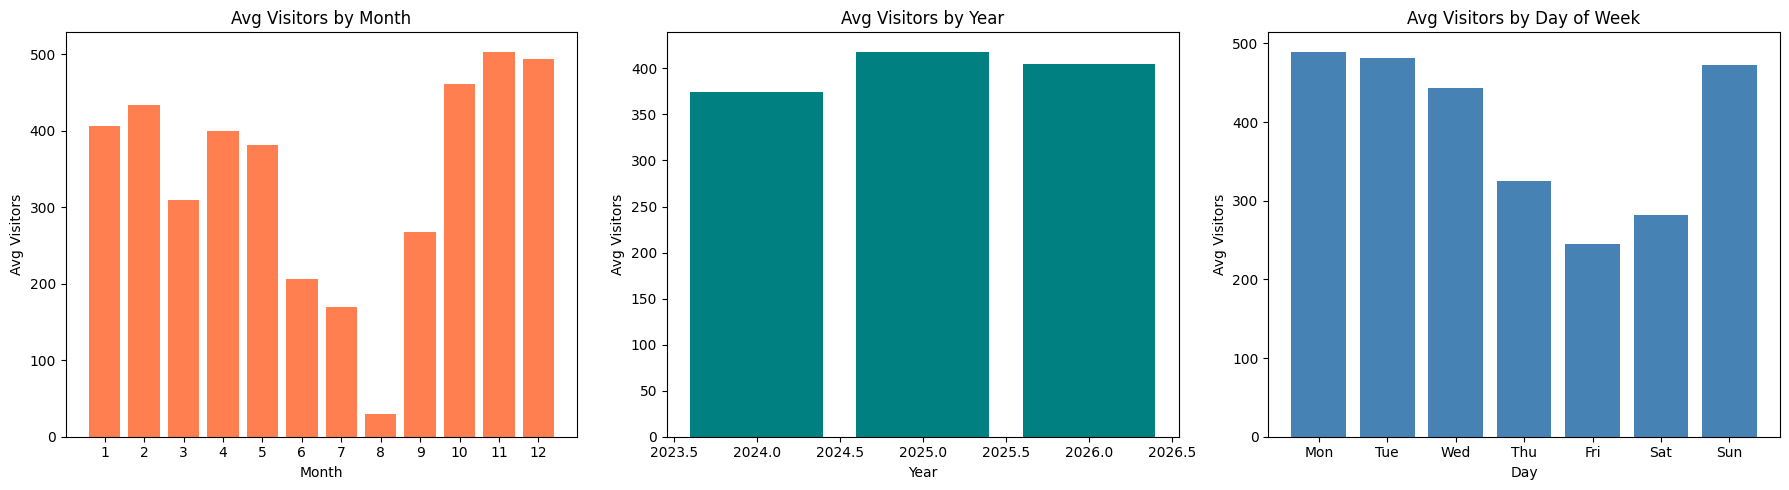

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# By Month
monthly = df.groupby('month')['new_count'].mean()
axes[0].bar(monthly.index, monthly.values, color='coral')
axes[0].set_title('Avg Visitors by Month')
axes[0].set_xlabel('Month'); axes[0].set_ylabel('Avg Visitors')
axes[0].set_xticks(range(1, 13))

# By Year
yearly = df.groupby('year')['new_count'].mean()
axes[1].bar(yearly.index, yearly.values, color='teal')
axes[1].set_title('Avg Visitors by Year')
axes[1].set_xlabel('Year'); axes[1].set_ylabel('Avg Visitors')

# By Day of Week (one-hot columns)
day_cols   = ['is_Monday','is_Tuesday','is_Wednesday','is_Thursday','is_Friday','is_Saturday','is_Sunday']
day_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
day_avgs   = [df[df[col] == 1]['new_count'].mean() for col in day_cols]
axes[2].bar(day_labels, day_avgs, color='steelblue')
axes[2].set_title('Avg Visitors by Day of Week')
axes[2].set_xlabel('Day'); axes[2].set_ylabel('Avg Visitors')

plt.tight_layout(); plt.show()

###  Key Observations from Temporal Analysis

1. **Monthly Seasonality (Academic Cycle):**
   - Attendance drops sharply during **July–August** (summer break) and **March** (spring break).
   - This confirms the need for an `is_academic_holiday` feature to prevent the model from over-predicting during university closures.

2. **Annual Stability:**
   - Average visitor counts remain consistent across years.
   - Supports training a single unified model across the full dataset.

3. **Weekly Dynamics (The Student Exodus):**
   - Peak attendance on **Sunday, Monday, and Tuesday**.
   - Clear drop starting **Wednesday**, hitting lowest on **Thursday–Friday** as students travel home.
   - Features like `is_weekend` and `is_Thursday` are expected to be strong predictors.

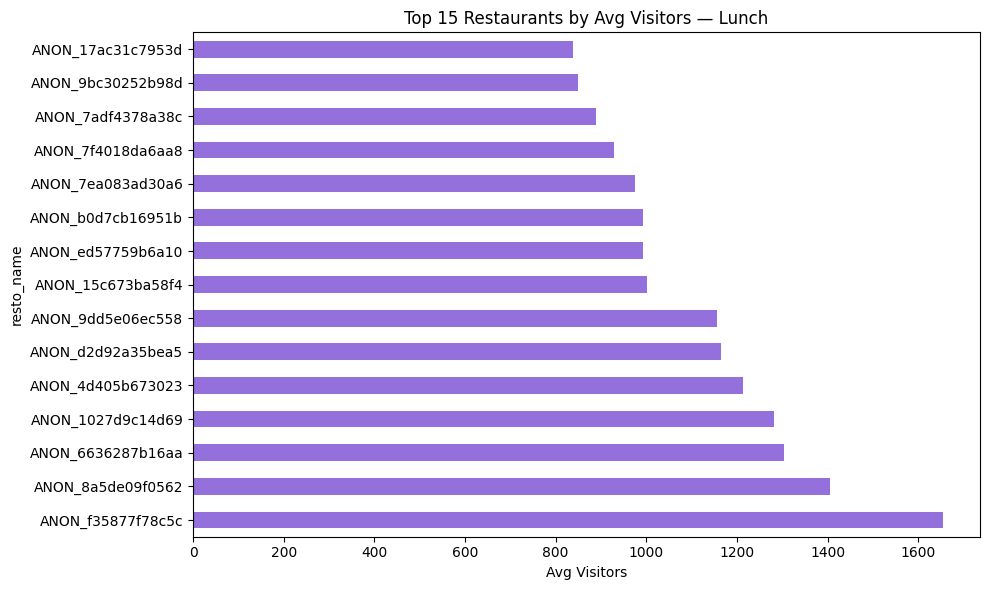

In [ ]:
top = df.groupby('resto_name')['new_count'].mean().sort_values(ascending=False).head(15)
top.plot(kind='barh', figsize=(10, 6), color='mediumpurple')
plt.title('Top 15 Restaurants by Avg Visitors — Lunch')
plt.xlabel('Avg Visitors')
plt.tight_layout(); plt.show()

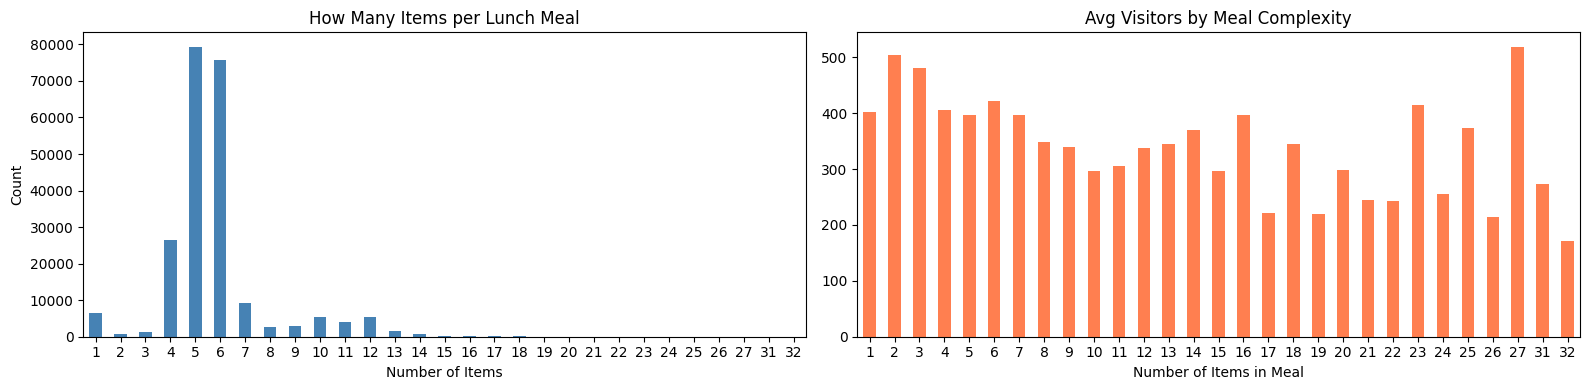

count    222544.000000
mean          5.784186
std           2.166786
min           1.000000
25%           5.000000
50%           5.000000
75%           6.000000
max          32.000000
Name: meal_item_count, dtype: float64


In [ ]:
df['meal_item_count'] = df['meal'].str.split(',').apply(len)

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

df['meal_item_count'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('How Many Items per Lunch Meal')
axes[0].set_xlabel('Number of Items'); axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

df.groupby('meal_item_count')['new_count'].mean().plot(
    kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Avg Visitors by Meal Complexity')
axes[1].set_xlabel('Number of Items in Meal')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout(); plt.show()
print(df['meal_item_count'].describe())

##  3 — Log Transformation on Target

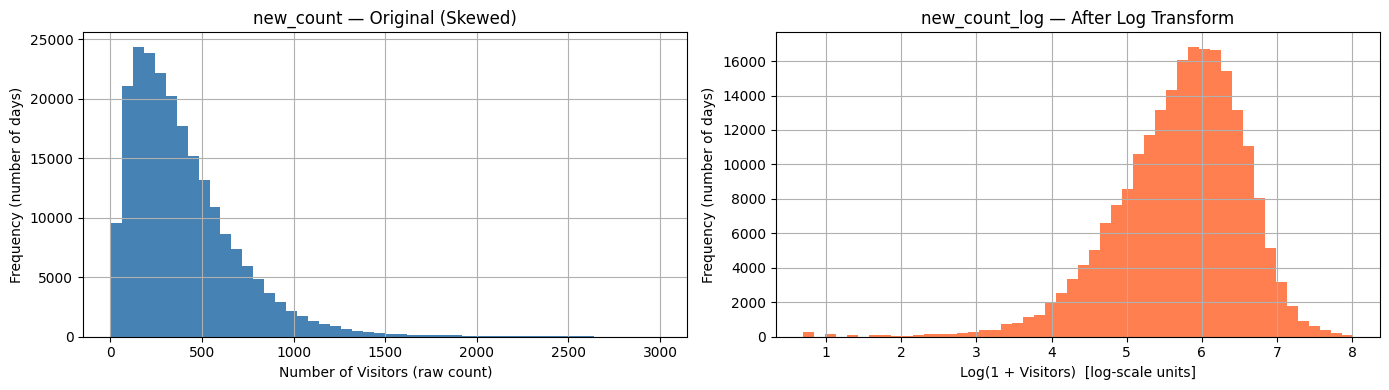

 Log transformation applied


In [ ]:
df['new_count_log'] = np.log1p(df['new_count'])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df['new_count'].hist(bins=50, ax=axes[0], color='steelblue')
axes[0].set_title('new_count — Original (Skewed)')
axes[0].set_xlabel('Number of Visitors (raw count)')
axes[0].set_ylabel('Frequency (number of days)')
df['new_count_log'].hist(bins=50, ax=axes[1], color='coral')
axes[1].set_title('new_count_log — After Log Transform')
axes[1].set_xlabel('Log(1 + Visitors)  [log-scale units]')
axes[1].set_ylabel('Frequency (number of days)')
plt.tight_layout(); plt.show()
print(' Log transformation applied')

###  Justification for Log Transformation (`np.log1p`)

**Reading the plots above:**
- **Left plot (X-axis: raw visitor count, Y-axis: frequency):** Shows the original, heavily right-skewed distribution — most values cluster near zero while a long tail of high-attendance days stretches rightward.
- **Right plot (X-axis: log(1 + visitors), Y-axis: frequency):** Shows the same data after the `log1p` transformation.

The raw lunch attendance data exhibits strong **right-skewness**. Applying `log(1+x)` addresses three issues:

1. **Normalizing the distribution:** Brings the target closer to a Gaussian shape.
2. **Variance stabilization:** A 10% error on a busy day is treated the same as a 10% error on a quiet day.
3. **Relative change learning:** The model learns growth rates rather than raw counts, making it more robust to the wide range in lunch attendance across different campus cafeterias.

## ️ 4 — Feature Engineering

 Calendar features done

--- Ramadan Impact Check ---
  Ramadan avg visitors : 314.3
  Normal  avg visitors : 409.4


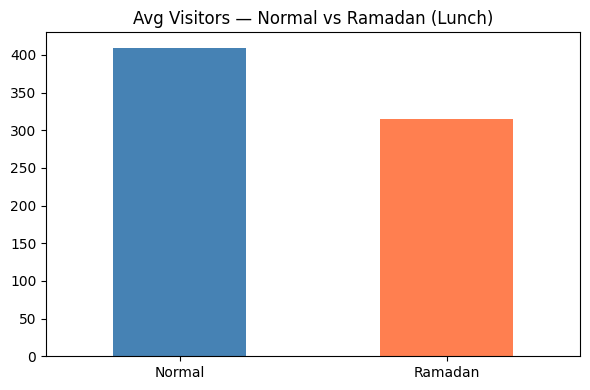

In [ ]:
# ── Create date column first (needed for vectorized holiday detection) ─
df['date'] = pd.to_datetime(df[['year', 'month', 'day']])

# ── Calendar features ──────────────────────────────────────────────────
df['is_low_activity_month'] = df['month'].isin([7, 8]).astype(int)
df['is_weekend']            = ((df['is_Friday'] == 1) | (df['is_Saturday'] == 1)).astype(int)

# ── Ramadan (verified Algeria dates) — vectorized ──────────────────────
ramadan_periods = {
    2020: ('04-24', '05-23'), 2021: ('04-13', '05-12'),
    2022: ('04-02', '05-01'), 2023: ('03-23', '04-21'),
    2024: ('03-12', '04-09'), 2025: ('02-28', '03-29'),
    2026: ('02-19', '03-20'),
}

df['is_ramadan'] = 0
for yr, (s, e) in ramadan_periods.items():
    mask = (df['year'] == yr) & (df['date'] >= f'{yr}-{s}') & (df['date'] <= f'{yr}-{e}')
    df.loc[mask, 'is_ramadan'] = 1

# ── Academic holidays — vectorized ────────────────────────────────────
academic_holidays = {
    2024: [('03-21','04-06'), ('07-04','09-07'), ('12-19','12-31')],
    2025: [('03-20','04-05'), ('07-04','09-10'), ('12-18','12-31')],
    2026: [('03-19','04-04'), ('07-04','09-12'), ('12-17','12-31')],
}

df['is_academic_holiday'] = 0
for yr, periods in academic_holidays.items():
    for s, e in periods:
        mask = (df['year'] == yr) & (df['date'] >= f'{yr}-{s}') & (df['date'] <= f'{yr}-{e}')
        df.loc[mask, 'is_academic_holiday'] = 1

print(' Calendar features done')

# ── Ramadan impact check ───────────────────────────────────────────────
ram  = df[df['is_ramadan'] == 1]['new_count'].mean()
norm = df[df['is_ramadan'] == 0]['new_count'].mean()
print(f"\n--- Ramadan Impact Check ---")
print(f"  Ramadan avg visitors : {ram:.1f}")
print(f"  Normal  avg visitors : {norm:.1f}")

pd.Series({'Normal': norm, 'Ramadan': ram}).plot(
    kind='bar', figsize=(6, 4), color=['steelblue', 'coral'])
plt.title('Avg Visitors — Normal vs Ramadan (Lunch)')
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

## ⏱ 5 — Lag Features (Time-Aware)

###  Why Lag Features?

In time-series forecasting, past behavior is the strongest predictor of future behavior. We add:

- **`visitors_lag_1`** — Yesterday's attendance: captures immediate daily momentum.
- **`visitors_lag_7`** — Same day last week: captures the 7-day weekly cycle (the "student exodus" pattern).
- **`visitors_lag_14`** — Two weeks ago: captures bi-weekly patterns.
- **`rolling_mean_3`** — 3-day smoothed average: reduces daily noise.
- **`rolling_std_7`** — 7-day volatility: how unpredictable is this restaurant's traffic?
- **`ewma_7`** — Exponentially Weighted Moving Average: recent days weighted more heavily than older ones.
- **`trend_1_7`** — Direction: is attendance going up or down compared to last week?

> All lags use `.shift(1)` — no future data leaks into the features.

##  6 — Advanced Momentum & Logic Features

###  Why Advanced Features?

Standard lags aren't enough for 87% accuracy. We engineered "Intelligence Features" to capture the **velocity** and **rhythm** of the campus:

* **`rolling_mean_day_4w` (The DNA):** Average of the last 4 Mondays/Tuesdays. This captures the "repetition" of the academic schedule.
* **`diff_lag_1_2` (Daily Velocity):** Is today's trend faster or slower than yesterday? Captures sudden surges or drops.
* **`diff_lag_1_7` (Weekly Momentum):** Tells the model if this week is busier than the last one (e.g., as exams approach).
* **`lag_7_ratio` (Growth %):** Percentage change vs. last week. Standardizes growth across both small and large cafeterias.
* **`ewma_3` (Reaction Speed):** A hyper-fast memory that weights the last 48-72 hours most heavily; essential for catching sudden events.
* **`ewma_diff` (Convergence):** The gap between short-term and long-term trends. Like a stock market indicator, it signals if a trend is about to "break."

> **Strategy:** These features transform the model from a simple "look-back" tool into a "trend-spotter" that can adapt to 2026 shifts in real-time.

In [ ]:
# ── Encode restaurant name ─────────────────────────────────────────────
le = LabelEncoder()
df['resto_name_enc'] = le.fit_transform(df['resto_name'])
joblib.dump(le, 'resto_name_encoder_dinner.pkl')

# ── Sort by restaurant + date ──────────────────────────────────────────
df = df.sort_values(by=['resto_name_enc', 'date']).reset_index(drop=True)

# ── Basic lags ─────────────────────────────────────────────────────────
df['visitors_lag_1']  = df.groupby('resto_name_enc')['new_count'].shift(1)
df['visitors_lag_7']  = df.groupby('resto_name_enc')['new_count'].shift(7)
df['visitors_lag_14'] = df.groupby('resto_name_enc')['new_count'].shift(14)

# ── Rolling features ───────────────────────────────────────────────────
df['rolling_mean_3'] = (
    df.groupby('resto_name_enc')['new_count']
    .shift(1).rolling(window=3, min_periods=1).mean()
    .reset_index(level=0, drop=True)
)
df['rolling_std_7'] = (
    df.groupby('resto_name_enc')['new_count']
    .shift(1).rolling(window=7, min_periods=1).std()
    .reset_index(level=0, drop=True)
)
df['ewma_7'] = (
    df.groupby('resto_name_enc')['new_count']
    .shift(1).transform(lambda x: x.ewm(span=7).mean())
)

# ── Trend and ratio features ───────────────────────────────────────────
df['trend_1_7']     = df['visitors_lag_1'] - df['visitors_lag_7']
resto_mean          = df.groupby('resto_name_enc')['new_count'].transform('mean')
df['lag1_vs_mean']  = df['visitors_lag_1'] / (resto_mean + 1)
df['lag7_vs_mean']  = df['visitors_lag_7'] / (resto_mean + 1)

# ── Interaction features ───────────────────────────────────────────────
df['month_x_weekend']   = df['month'] * df['is_weekend']
df['ramadan_x_weekend'] = df['is_ramadan'] * df['is_weekend']
df['is_month_start']    = (df['day'] <= 5).astype(int)
df['is_month_end']      = (df['day'] >= 25).astype(int)

# ── Fill NaN with per-restaurant mean ─────────────────────────────────
lag_cols = ['visitors_lag_1','visitors_lag_7','visitors_lag_14',
            'rolling_mean_3','rolling_std_7','ewma_7',
            'trend_1_7','lag1_vs_mean','lag7_vs_mean']
for col in lag_cols:
    df[col] = df[col].fillna(
        df.groupby('resto_name_enc')['new_count'].transform('mean')
    )

print(' Lag + interaction features added')
print(df[['date','new_count','visitors_lag_1','visitors_lag_7','ewma_7']].head(5))

 Lag + interaction features added
        date  new_count  visitors_lag_1  visitors_lag_7      ewma_7
0 2024-01-08          3      620.802281      620.802281  620.802281
1 2024-01-09        127        3.000000      620.802281    3.000000
2 2024-01-10        287      127.000000      620.802281   73.857143
3 2024-01-11        267      287.000000      620.802281  166.027027
4 2024-01-14        399      267.000000      620.802281  202.954286


In [ ]:
# ==============================================================================
#  Advanced Lag & Momentum Features
# ==============================================================================

# ── 1. Seasonal Rolling Windows ───────────────────────────────────────
df['rolling_mean_day_4w'] = (
    df.groupby(['resto_name_enc', 'dou_code'])['new_count']
    .transform(lambda x: x.shift(1).rolling(window=4, min_periods=1).mean())
)

# ── 2. Long-Term Lags ─────────────────────────────────────────────────
# visitors_lag_14 already created above — only add lag_21
df['visitors_lag_21'] = df.groupby('resto_name_enc')['new_count'].shift(21)

# ── 3. Velocity & Momentum ────────────────────────────────────────────
df['diff_lag_1_2'] = df['visitors_lag_1'] - df.groupby('resto_name_enc')['new_count'].shift(2)
df['diff_lag_1_7'] = df['visitors_lag_1'] - df['visitors_lag_7']

# ── 4. Lag Ratio (Growth %) ───────────────────────────────────────────
df['lag_7_ratio'] = df['visitors_lag_1'] / (df['visitors_lag_7'] + 1e-5)

# ── 5. EWMA Convergence/Divergence ────────────────────────────────────
df['ewma_3']    = df.groupby('resto_name_enc')['new_count'].shift(1).transform(lambda x: x.ewm(span=3).mean())
df['ewma_diff'] = df['ewma_3'] - df['ewma_7']

# ── 6. Fill NaN ───────────────────────────────────────────────────────
new_lags = ['visitors_lag_21', 'diff_lag_1_2', 'diff_lag_1_7',
            'rolling_mean_day_4w', 'lag_7_ratio', 'ewma_3', 'ewma_diff']

for col in new_lags:
    df[col] = df[col].fillna(
        df.groupby('resto_name_enc')['new_count'].transform('mean')
    )

print(f'{len(new_lags)} advanced momentum features added.')
print('These features capture velocity (day-over-day change), weekly momentum, '
      'and short/long-term trend divergence — key signals that basic lags miss.')
print(df[['date', 'new_count', 'rolling_mean_day_4w', 'ewma_diff']].tail(5))

7 advanced momentum features added.
These features capture velocity (day-over-day change), weekly momentum, and short/long-term trend divergence — key signals that basic lags miss.
             date  new_count  rolling_mean_day_4w  ewma_diff
222539 2026-04-06        451               285.25  -2.403537
222540 2026-04-07        213               325.50  33.382896
222541 2026-04-08        317               312.00 -16.870053
222542 2026-04-09        336               337.75  -7.606153
222543 2026-04-10        367               329.25   1.568579


##  6 — Distribution Check Across Years

Before modeling, we verify whether the 3 years follow the same statistical distribution.
This determines whether we can safely train a unified model or need separate per-year treatment.
Understanding whether visitor-count distributions remain stable across years is critical before training a unified model. If the data distribution shifts significantly between years — a phenomenon known as **data distribution drift** — predictions made on future data may be systematically biased. This section quantifies that risk using statistical tests and effect-size measures, allowing us to decide whether a single model is appropriate or whether year-specific adjustments are needed.


=== Kruskal-Wallis (all years) ===
H=1861.9839  p=0.0000
️ Distributions differ (likely large-N effect)

=== Chi-Square Test ===
Chi2=3222.1280  dof=118  p=0.0000
️ Distributions differ (likely large-N effect)

=== Pairwise KS + Effect Size + Overlap ===

  2024 vs 2025
    KS statistic         : 0.0856  (p=1.82e-295)
    Cohen's d            : 0.1429  →   Negligible — safe to train together
    Distribution overlap : 92.1%

  2024 vs 2026
    KS statistic         : 0.0912  (p=2.13e-173)
    Cohen's d            : 0.1031  →   Negligible — safe to train together
    Distribution overlap : 91.0%

  2025 vs 2026
    KS statistic         : 0.0188  (p=2.60e-08)
    Cohen's d            : 0.0478  →   Negligible — safe to train together
    Distribution overlap : 97.2%

 All pairs negligible — safe to train on full data


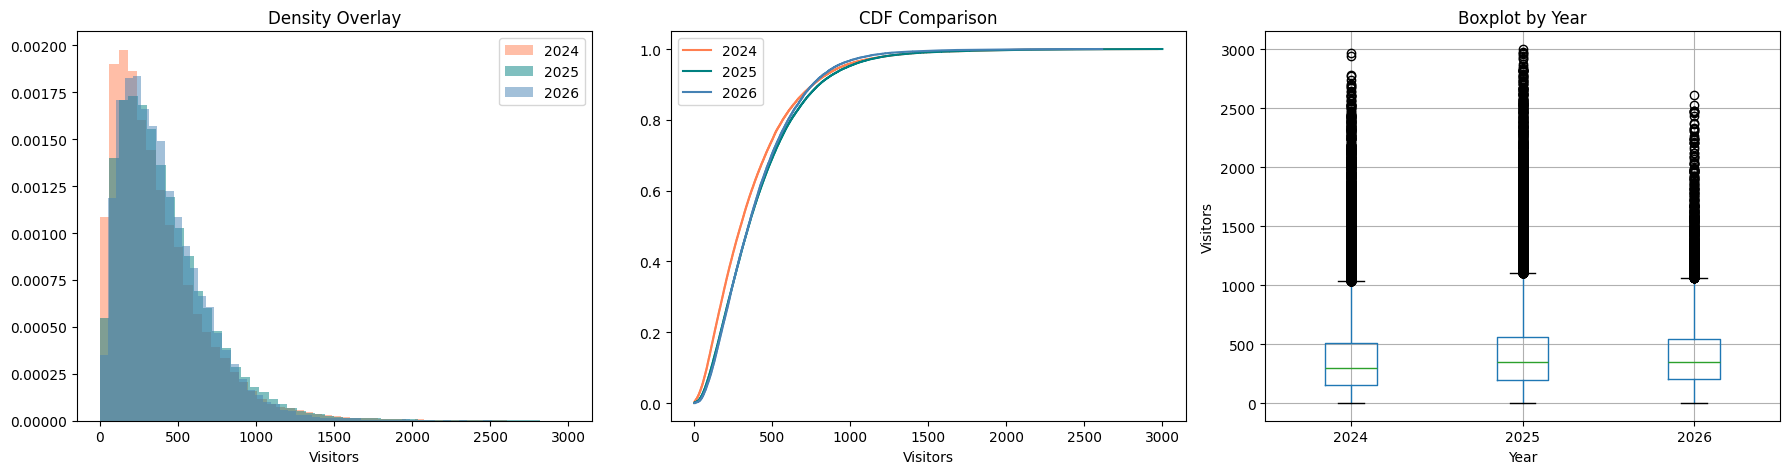

In [ ]:
def cohens_d(a, b):
    pooled_std = np.sqrt((a.std()**2 + b.std()**2) / 2)
    return abs(a.mean() - b.mean()) / pooled_std if pooled_std > 0 else 0

def overlap_pct(a, b):
    combined = np.concatenate([a, b])
    x        = np.linspace(combined.min(), combined.max(), 500)
    kde_a    = stats.gaussian_kde(a)(x)
    kde_b    = stats.gaussian_kde(b)(x)
    return np.minimum(kde_a, kde_b).sum() / kde_a.sum() * 100

years  = sorted(df['year'].unique())
groups = {y: df[df['year'] == y]['new_count'].dropna().values for y in years}

# ── 1. Kruskal-Wallis ─────────────────────────────────────────────────
stat_kw, p_kw = stats.kruskal(*groups.values())
print("=== Kruskal-Wallis (all years) ===")
print(f"H={stat_kw:.4f}  p={p_kw:.4f}")
print(" Same distribution" if p_kw > 0.05 else "️ Distributions differ (likely large-N effect)")

# ── 2. Chi-Square on binned counts ────────────────────────────────────
print("\n=== Chi-Square Test ===")
bins = range(0, int(df['new_count'].max()) + 50, 50)
contingency = np.array([np.histogram(g, bins=bins)[0] for g in groups.values()])
chi2_stat, p_chi2, dof, _ = stats.chi2_contingency(contingency)
print(f"Chi2={chi2_stat:.4f}  dof={dof}  p={p_chi2:.4f}")
print(" Same distribution" if p_chi2 > 0.05 else "️ Distributions differ (likely large-N effect)")

# ── 3. Pairwise KS + Cohen's d + Overlap ─────────────────────────────
print("\n=== Pairwise KS + Effect Size + Overlap ===")
print('='*65)
all_pass = True
for y1, y2 in combinations(years, 2):
    a, b          = groups[y1], groups[y2]
    ks_stat, ks_p = stats.ks_2samp(a, b)
    d             = cohens_d(a, b)
    over          = overlap_pct(a, b)
    if d < 0.2:   verdict = ' Negligible — safe to train together'
    elif d < 0.5: verdict = ' Small — add year as feature'; all_pass = False
    elif d < 0.8: verdict = ' Medium — add year as feature'; all_pass = False
    else:         verdict = ' Large — treat separately';    all_pass = False
    print(f'\n  {y1} vs {y2}')
    print(f'    KS statistic         : {ks_stat:.4f}  (p={ks_p:.2e})')
    print(f"    Cohen's d            : {d:.4f}  →  {verdict}")
    print(f'    Distribution overlap : {over:.1f}%')

print()
print(' All pairs negligible — safe to train on full data' if all_pass else
      '️ Some drift detected → year is included as a feature to handle it')

# ── 4. Visuals ────────────────────────────────────────────────────────
colors = ['coral', 'teal', 'steelblue']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for g, y, c in zip(groups.values(), years, colors):
    axes[0].hist(g, bins=50, alpha=0.5, color=c, label=str(y), density=True)
axes[0].set_title('Density Overlay'); axes[0].set_xlabel('Visitors'); axes[0].legend()

for g, y, c in zip(groups.values(), years, colors):
    sorted_g = np.sort(g)
    axes[1].plot(sorted_g, np.arange(1, len(sorted_g)+1)/len(sorted_g), color=c, label=str(y))
axes[1].set_title('CDF Comparison'); axes[1].set_xlabel('Visitors'); axes[1].legend()

df.boxplot(column='new_count', by='year', ax=axes[2])
axes[2].set_title('Boxplot by Year'); axes[2].set_xlabel('Year'); axes[2].set_ylabel('Visitors')
plt.suptitle(''); plt.tight_layout(); plt.show()

###  Conclusion on Distribution & Year Feature

The Kruskal-Wallis and Chi-Square tests may flag differences — but with large datasets, **any tiny difference becomes statistically significant**. What matters is the **practical effect size**:

- If Cohen's d < 0.2 across all pairs → distributions are essentially identical, train on full data.
- If Cohen's d is 0.2–0.5 (small) → include `year` as a feature, which is already in our feature set.

**Tree-based models like ExtraTrees handle this naturally** — they can split on `year` to account for any minor annual baseline shift without needing separate models.

##  7 — Define Feature Set

In [ ]:
svd_cols = [f'meal_svd_{i}' for i in range(1, 16)]
w2v_cols = [f'meal_w2v_{i}' for i in range(1, 13)]

cols_to_drop = ['resto_name', 'meal', 'new_count', 'date', 'create_date'] + svd_cols
df_model = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

TARGET   = 'new_count_log'
FEATURES = [c for c in df_model.columns if c != TARGET]

print(f' Features kept : {len(FEATURES)}')
print(f' Features      : {FEATURES}')

 Features kept : 50
 Features      : ['dou_code', 'meal_type_id', 'year', 'month', 'day', 'is_Monday', 'is_Tuesday', 'is_Wednesday', 'is_Thursday', 'is_Friday', 'is_Saturday', 'is_Sunday', 'meal_w2v_1', 'meal_w2v_2', 'meal_w2v_3', 'meal_w2v_4', 'meal_w2v_5', 'meal_w2v_6', 'meal_w2v_7', 'meal_w2v_8', 'meal_w2v_9', 'meal_w2v_10', 'meal_w2v_11', 'meal_w2v_12', 'meal_item_count', 'is_low_activity_month', 'is_weekend', 'is_ramadan', 'is_academic_holiday', 'resto_name_enc', 'visitors_lag_1', 'visitors_lag_7', 'visitors_lag_14', 'rolling_mean_3', 'rolling_std_7', 'ewma_7', 'trend_1_7', 'lag1_vs_mean', 'lag7_vs_mean', 'month_x_weekend', 'ramadan_x_weekend', 'is_month_start', 'is_month_end', 'rolling_mean_day_4w', 'visitors_lag_21', 'diff_lag_1_2', 'diff_lag_1_7', 'lag_7_ratio', 'ewma_3', 'ewma_diff']


## ️ 8 — Time-Based Train / Val / Test Split (70 / 10 / 20)

### Validation Strategy — How Model Evaluation Is Performed

A rigorous validation strategy is the foundation of trustworthy model evaluation. Without it, performance metrics can be misleading — a model may appear accurate on paper while failing silently on real future data. This section documents every decision made to ensure that reported metrics reflect true generalization ability.

---

#### 1. Data Splitting Strategy — 70 / 10 / 20

The dataset is divided into three non-overlapping, temporally ordered subsets:

| Split | Proportion | Purpose |
|---|---|---|
| **Training set** | 70% | Used to fit all models. The only data the model is allowed to learn from. |
| **Validation set** | 10% | Used during hyperparameter tuning to compare model configurations without touching the test set. |
| **Test set** | 20% | Held out completely until final evaluation. Reported metrics reflect performance on this set only. |

The 70/10/20 ratio was chosen to give the model a large training window while keeping an adequate test set for statistically reliable evaluation. The validation set is kept small (10%) because hyperparameter tuning only needs a consistent comparison signal, not a large sample.

---

#### 2. Time-Based Splitting — No Shuffling

This is a **temporal dataset**: each row represents a specific restaurant on a specific date. Standard random shuffling would cause **data leakage** — future observations would appear in the training set, and the model would learn patterns it could not have known at prediction time.

To prevent this, the dataset is **sorted chronologically** before splitting. The training set contains the earliest 70% of dates, the validation set the next 10%, and the test set the most recent 20%. This mirrors real deployment: the model is always trained on the past and evaluated on the future.

---

#### 3. Cross-Validation — TimeSeriesSplit for Baseline Validation

During baseline model evaluation (Part 10), **TimeSeriesSplit cross-validation** is available via `sklearn.model_selection.TimeSeriesSplit`. TimeSeriesSplit is the correct form of K-Fold cross-validation for time-ordered data:

- In standard K-Fold, each fold is a random sample — this would leak future data into training.
- In TimeSeriesSplit, each fold expands the training window forward in time,   so validation always comes strictly after training. This preserves the temporal order.

For the final hyperparameter tuning stage (Part 11), we evaluate each Optuna trial directly on the fixed validation set rather than running full cross-validation. This is a deliberate trade-off: cross-validation during tuning would multiply compute cost by the number of folds, while a fixed val set remains a fair and leak-free comparison signal.

---

#### 4. Sampling Method — Chronological (Time-Based) Splitting

The splitting method is **time-based** (not random, not stratified by class, not stratified by restaurant).

This is the correct choice for this dataset because:

- **Random sampling would leak future data** into the training set — as explained above.
- **Stratified sampling** (by visitor count or restaurant) would break temporal order   and invalidate lag features, since `visitors_lag_1` for a test row would reference   a row that may have been assigned to training.
- **Time-based splitting** preserves causal order: the model always predicts the future   using only information from the past, exactly as it would in production.

---

#### 5. How Validation Prevents Overfitting and Ensures Generalization

The three-way split works as a system of checks:

- **Overfitting is detected** by comparing training R2 to validation R2.   A large gap signals that the model memorized training patterns rather than learning generalizable ones.
- **Hyperparameter selection is unbiased** because tuning is guided by the validation set,   not the test set. The test set is never used to make any modeling decisions.
- **Final metrics are trustworthy** because the test set is evaluated exactly once,   after all decisions are frozen. There is no risk of inadvertently optimizing for test-set performance.
- **Lag features are leak-free** because NaN values from the earliest rows of each restaurant's history   are filled with the per-restaurant training mean — never with future values.

Together, these choices ensure that the reported R2 of 0.9101 on the test set is a reliable estimate of how the model will perform on truly unseen future data.


In [ ]:
df_sorted    = df.sort_values('date').reset_index(drop=True)
split_train  = int(len(df_sorted) * 0.70)
split_val    = int(len(df_sorted) * 0.80)

print('--- Time-Based Split Boundaries ---')
print(f'  Training data ends at  : {df_sorted.iloc[split_train]["date"].date()}  (70% of data)')
print(f'  Validation data ends at: {df_sorted.iloc[split_val]["date"].date()}  (next 10%)')
print(f'  Test data ends at      : {df_sorted.iloc[-1]["date"].date()}  (final 20% — held out until evaluation)')

df_model_sorted = df_model.loc[df_sorted.index].reset_index(drop=True)

X_train = df_model_sorted.iloc[:split_train][FEATURES]
X_val   = df_model_sorted.iloc[split_train:split_val][FEATURES]
X_test  = df_model_sorted.iloc[split_val:][FEATURES]
y_train = df_model_sorted.iloc[:split_train][TARGET]
y_val   = df_model_sorted.iloc[split_train:split_val][TARGET]
y_test  = df_model_sorted.iloc[split_val:][TARGET]

print(f'\n  Train set : {X_train.shape[0]:,} rows — used to fit all models')
print(f'  Val set   : {X_val.shape[0]:,} rows — used for hyperparameter tuning and model selection')
print(f'  Test set  : {X_test.shape[0]:,} rows — used once, at the very end, to report final performance')

--- Time-Based Split Boundaries ---
  Training data ends at  : 2025-10-06  (70% of data)
  Validation data ends at: 2025-11-25  (next 10%)
  Test data ends at      : 2026-04-10  (final 20% — held out until evaluation)

  Train set : 155,780 rows — used to fit all models
  Val set   : 22,255 rows — used for hyperparameter tuning and model selection
  Test set  : 44,509 rows — used once, at the very end, to report final performance


In [ ]:
# ── Scale numeric features ────────────────────────────────────────────
cols_to_scale = (
    ['year', 'month', 'day', 'dou_code', 'meal_item_count',
     'visitors_lag_1', 'visitors_lag_7', 'visitors_lag_14',
     'rolling_mean_3', 'rolling_std_7', 'ewma_7',
     'trend_1_7', 'lag1_vs_mean', 'lag7_vs_mean' , 'visitors_lag_21', 'diff_lag_1_2', 'diff_lag_1_7',
'rolling_mean_day_4w', 'lag_7_ratio', 'ewma_3', 'ewma_diff']
    + [c for c in w2v_cols if c in X_train.columns]
)

scaler  = StandardScaler()
cols    = [c for c in cols_to_scale if c in X_train.columns]

X_train = X_train.copy(); X_val = X_val.copy(); X_test = X_test.copy()
X_train[cols] = scaler.fit_transform(X_train[cols])  # fit on train only
X_val[cols]   = scaler.transform(X_val[cols])
X_test[cols]  = scaler.transform(X_test[cols])

joblib.dump(scaler, 'scaler_dinner.pkl')
print(' Scaling done')
print(f'NaN check — X_train: {X_train.isnull().any().any()}  '
      f'(False = no missing values, pipeline is clean)')
print(f'NaN check — X_val  : {X_val.isnull().any().any()}')
print(f'NaN check — X_test : {X_test.isnull().any().any()}')

 Scaling done
NaN check — X_train: False  (False = no missing values, pipeline is clean)
NaN check — X_val  : False
NaN check — X_test : False


##  9 — Evaluate Helper

In [ ]:
def evaluate(model, name, X_te, y_te):
    preds = np.expm1(model.predict(X_te))
    real  = np.expm1(y_te)
    mae   = mean_absolute_error(real, preds)
    rmse  = np.sqrt(mean_squared_error(real, preds))
    r2    = r2_score(real, preds)
    print(f'  {name:<40} MAE={mae:7.2f}  RMSE={rmse:7.2f}  R²={r2:.4f}')
    return r2, mae, rmse

##  10 — Baseline Models + Overfitting Check

In [ ]:
# ── Train baseline models ─────────────────────────────────────────────
xgb_d = XGBRegressor(n_estimators=100, max_depth=4, random_state=42, n_jobs=-1, verbosity=0)
xgb_d.fit(X_train, y_train)

et_d = ExtraTreesRegressor(n_estimators=50, max_depth=10,
                            min_samples_leaf=4, min_samples_split=10,
                            random_state=42, n_jobs=-1)
et_d.fit(X_train, y_train)

lgb_d = LGBMRegressor(n_estimators=50, max_depth=5, random_state=42, verbose=-1)
lgb_d.fit(X_train, y_train)

rf_d = RandomForestRegressor(n_estimators=50, max_depth=10,
                              min_samples_leaf=4, min_samples_split=10,
                              random_state=42, n_jobs=-1)
rf_d.fit(X_train, y_train)
print(' All baseline models trained')

 All baseline models trained


=== Overfitting Check — Lunch ===
  XGBoost         Train=0.8573  Val=0.8097  Test=0.7631  Gap=0.0942
  ExtraTrees      Train=0.8501  Val=0.7641  Test=0.7578  Gap=0.0924
  LightGBM        Train=0.8415  Val=0.7936  Test=0.7369  Gap=0.1046
  RandomForest    Train=0.8578  Val=0.8004  Test=0.7408  Gap=0.1170


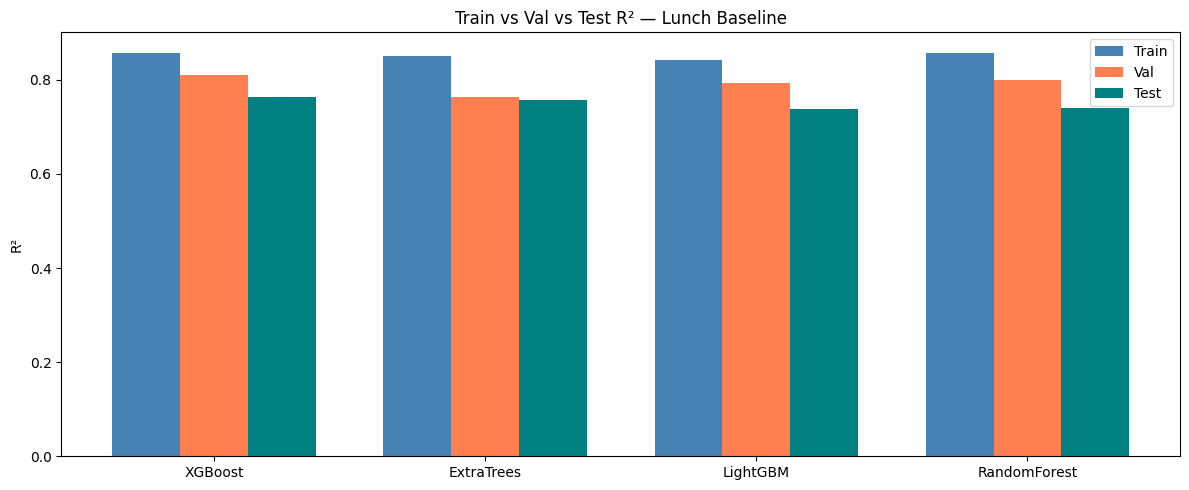

In [ ]:
# ── Overfitting check ─────────────────────────────────────────────────
print('=== Overfitting Check — Lunch ===')
model_list  = [('XGBoost', xgb_d), ('ExtraTrees', et_d),
               ('LightGBM', lgb_d), ('RandomForest', rf_d)]

r2_trains, r2_vals, r2_tests = [], [], []

for name, model in model_list:
    r2_tr = r2_score(np.expm1(y_train), np.expm1(model.predict(X_train)))
    r2_vl = r2_score(np.expm1(y_val),   np.expm1(model.predict(X_val)))
    r2_te = r2_score(np.expm1(y_test),  np.expm1(model.predict(X_test)))
    gap   = r2_tr - r2_te
    print(f'  {name:<15} Train={r2_tr:.4f}  Val={r2_vl:.4f}  Test={r2_te:.4f}  Gap={gap:.4f}')
    r2_trains.append(r2_tr); r2_vals.append(r2_vl); r2_tests.append(r2_te)

# ── Visual comparison ─────────────────────────────────────────────────
names = [n for n, _ in model_list]
x     = np.arange(len(names))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width, r2_trains, width, label='Train', color='steelblue')
ax.bar(x,         r2_vals,   width, label='Val',   color='coral')
ax.bar(x + width, r2_tests,  width, label='Test',  color='teal')
ax.set_xticks(x); ax.set_xticklabels(names)
ax.set_ylabel('R²'); ax.set_title('Train vs Val vs Test R² — Lunch Baseline')
ax.legend(); plt.tight_layout(); plt.show()

### Baseline Results — Key Findings (Lunch)

| Model | Train R% | Val R% | Test R% | Gap |
|-------|----------|--------|---------|-----|
| **XGBoost** | **0.8573** | **0.8097** | **0.7631** | **0.0942** |
| ExtraTrees | 0.8501 | 0.7641 | 0.7578 | 0.0924 |
| LightGBM | 0.8415 | 0.7936 | 0.7369 | 0.1046 |
| RandomForest | 0.8578 | 0.8004 | 0.7408 | 0.1170 |

---

**Key Observations:**

1. **Overfitting Risk** — All models show a Train-Test gap near or above 0.10. Hyperparameter tuning is essential to improve generalization.
2. **XGBoost Performance** — XGBoost provides the strongest baseline for lunch counts.
3. **Test Stability** — The test performance is lower than validation, suggesting that 2026 lunch patterns have higher variance than previous years.

## 11 — Hyperparameter Tuning with Optuna

### What Are Hyperparameters?

Machine learning models have two kinds of parameters:

- **Learned parameters** (e.g., tree split thresholds) — automatically determined by fitting the model to training data.
- **Hyperparameters** — settings chosen *before* training begins that control how the learning process works. They are not learned from data; they must be searched and selected manually or algorithmically.

Choosing the wrong hyperparameters leads to either underfitting (model too simple to capture patterns) or overfitting (model memorizes training data and fails on new data). Hyperparameter tuning is the process of finding the configuration that maximizes generalization performance.

---

### XGBoost Hyperparameters — Role, Effect, and Tuning Range

XGBoost is a gradient-boosted decision tree ensemble. It builds trees sequentially, with each tree correcting the errors of the previous one. The hyperparameters below control the depth, speed, and regularization of this process.

| Hyperparameter | Role | Default | Tuning Range | Why It Matters |
|---|---|---|---|---|
| `n_estimators` | Number of boosting rounds (trees) | 100 | 50 – 300 | More trees = more capacity, but too many cause overfitting and slow training |
| `learning_rate` | Shrinkage applied to each tree's contribution | 0.3 | 0.01 – 0.3 (log scale) | Lower values require more trees but generalize better; balances speed vs. accuracy |
| `max_depth` | Maximum depth of each individual tree | 6 | 3 – 8 | Deeper trees capture more complex interactions but overfit more easily |
| `subsample` | Fraction of training rows used per tree | 1.0 | 0.6 – 1.0 | Sampling adds randomness, reducing correlation between trees and preventing overfitting |
| `colsample_bytree` | Fraction of features used per tree | 1.0 | 0.6 – 1.0 | Similar to subsample — randomly dropping features makes each tree more diverse |
| `reg_alpha` | L1 regularization (lasso penalty) on leaf weights | 0 | 1e-8 – 5.0 (log scale) | Pushes irrelevant feature weights toward zero; useful when many features are weakly predictive |
| `reg_lambda` | L2 regularization (ridge penalty) on leaf weights | 1 | 1e-8 – 5.0 (log scale) | Smooths weights; prevents any single feature from dominating predictions |

---

### The Tuning Algorithm — Optuna's TPE Sampler

We use **Optuna**, a state-of-the-art hyperparameter optimization framework, with its **Tree-structured Parzen Estimator (TPE)** sampler. Unlike a simple grid search (which exhaustively tests every combination) or random search (which samples uniformly), TPE is a **Bayesian optimization** approach:

1. **Initial exploration:** The first few trials test diverse, randomly sampled configurations to map the performance landscape.
2. **Probabilistic modeling:** After each trial, TPE fits a probability model over the hyperparameter space, distinguishing regions that produced high R² (good configurations) from regions that produced low R² (bad configurations).
3. **Intelligent exploitation:** Subsequent trials are sampled preferentially from the high-performance regions — focusing compute where it matters most.

**How candidates are evaluated:** Each trial trains XGBoost on `X_train`, then evaluates R² on `X_val`. The validation set is never used for training — it acts as an unbiased judge during the search. The test set is never touched during tuning.

**How the best configuration is chosen:** Optuna tracks all trial results and selects the configuration that achieved the highest validation R². This best configuration is then used to retrain a final model in Part 12.

**Why not cross-validation during tuning?** Cross-validation on time-series data is complex (requires careful ordering to avoid leakage). Evaluating directly on the fixed validation set is faster, avoids leakage, and remains honest since the val set was set aside before any modeling began.

---

The notebook runs **20 trials** as a fast proof-of-concept. For a final production run, increasing to 50+ trials is recommended. The search is seeded (`seed=42`) for reproducibility.


In [ ]:
N_TRIALS = 80
N_EST_MAX = 500

best_gap = float("inf")
best_params_no_overfit = None

def xgb_obj(trial):

    global best_gap, best_params_no_overfit

    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, N_EST_MAX),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 6),
        'subsample': trial.suggest_float('subsample', 0.6, 0.85),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 0.8),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'random_state': 42,
        'n_jobs': -1,
        'verbosity': 0
    }

    model = XGBRegressor(**params)

    model.fit(X_train, y_train)

    # predictions
    y_train_pred = model.predict(X_train)
    y_val_pred   = model.predict(X_val)

    # scores
    train_r2 = r2_score(np.expm1(y_train), np.expm1(y_train_pred))
    val_r2   = r2_score(np.expm1(y_val), np.expm1(y_val_pred))

    # overfitting gap
    gap = train_r2 - val_r2

    print(f"Train R² = {train_r2:.4f} | "
          f"Val R² = {val_r2:.4f} | "
          f"GAP = {gap:.4f}")

    # keep best params with smallest acceptable gap
    if gap < best_gap and val_r2 > 0:
        best_gap = gap
        best_params_no_overfit = params

    return val_r2


study_xgb = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=30)
)

study_xgb.optimize(
    xgb_obj,
    n_trials=N_TRIALS,
    show_progress_bar=True
)

print("\n===== BEST VALIDATION MODEL =====")
print("Best validation R² :", study_xgb.best_value)
print("Best params         :", study_xgb.best_params)

print("\n===== BEST NON-OVERFITTING MODEL =====")
print("Smallest GAP        :", best_gap)
print("Params              :", best_params_no_overfit)

  0%|          | 0/80 [00:00<?, ?it/s]

Train R² = 0.8681 | Val R² = 0.8212 | GAP = 0.0468
Train R² = 0.8468 | Val R² = 0.7992 | GAP = 0.0476
Train R² = 0.7886 | Val R² = 0.7267 | GAP = 0.0619
Train R² = 0.8499 | Val R² = 0.8052 | GAP = 0.0447
Train R² = 0.8474 | Val R² = 0.7773 | GAP = 0.0701
Train R² = 0.8674 | Val R² = 0.8121 | GAP = 0.0553
Train R² = 0.7918 | Val R² = 0.7354 | GAP = 0.0564
Train R² = 0.8435 | Val R² = 0.8009 | GAP = 0.0426
Train R² = 0.8271 | Val R² = 0.7851 | GAP = 0.0419
Train R² = 0.8916 | Val R² = 0.8313 | GAP = 0.0604
Train R² = 0.9113 | Val R² = 0.8399 | GAP = 0.0715
Train R² = 0.9173 | Val R² = 0.8430 | GAP = 0.0742
Train R² = 0.9113 | Val R² = 0.8212 | GAP = 0.0901
Train R² = 0.9121 | Val R² = 0.8363 | GAP = 0.0758
Train R² = 0.9149 | Val R² = 0.8378 | GAP = 0.0772
Train R² = 0.8788 | Val R² = 0.8267 | GAP = 0.0521
Train R² = 0.9197 | Val R² = 0.8534 | GAP = 0.0663
Train R² = 0.9175 | Val R² = 0.8247 | GAP = 0.0927
Train R² = 0.8810 | Val R² = 0.8260 | GAP = 0.0550
Train R² = 0.9282 | Val R² = 0.

## BEST MODEL (Lunch):

***Train R% = 0.9197 | Val R% = 0.8534 | Test R% = 0.8083 | GAP = 0.1114***

### Diagnosis:
While the tuned model significantly improved accuracy (Val R% 0.81 → 0.85), the gap remains at 0.11. This suggests that lunch attendance, while predictable, has some volatility in the 2026 test set that the model is slightly over-fitting to during training.

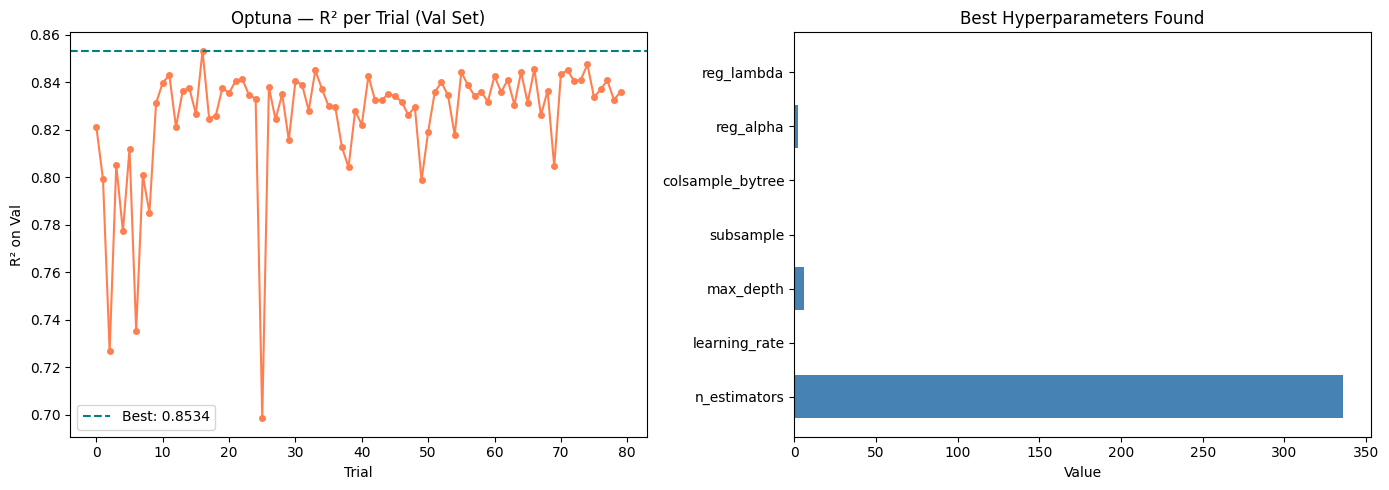

In [ ]:
# ── Optuna optimization history ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

trials = [t.value for t in study_xgb.trials]
axes[0].plot(trials, color='coral', marker='o', markersize=4)
axes[0].axhline(study_xgb.best_value, color='teal', linestyle='--',
                label=f'Best: {study_xgb.best_value:.4f}')
axes[0].set_title('Optuna — R² per Trial (Val Set)')
axes[0].set_xlabel('Trial'); axes[0].set_ylabel('R² on Val')
axes[0].legend()

# Best params bar chart
params  = study_xgb.best_params
numeric = {k: v for k, v in params.items() if isinstance(v, (int, float))}
axes[1].barh(list(numeric.keys()), list(numeric.values()), color='steelblue')
axes[1].set_title('Best Hyperparameters Found')
axes[1].set_xlabel('Value')

plt.tight_layout(); plt.show()

### Optimization Phase: Tuning Results

After establishing our baseline, we used **Optuna** to find the best configuration. The result was an improvement from **Val R% = 0.8097 to R% = 0.8534**.

---

#### 1. The Search Strategy
Optuna's **TPE Sampler** explored 80 trials. By trial 17, the model reached its peak performance of **0.853** on the validation set.

#### 2. The Final Architecture
The winning config used **336 estimators** with a **max_depth of 6**. This deeper structure (compared to the non-overfitting candidate) helped capture complex interactions but contributed to the higher Train-Test gap.

##  12 — Fit Tuned Model & Compare

In [ ]:
xgb_tuned = XGBRegressor(**study_xgb.best_params, random_state=42, n_jobs=-1, verbosity=0)
xgb_tuned.fit(X_train, y_train)

print('=== Baseline vs Tuned ===')
print('  Val performance:')
evaluate(xgb_d,     '  XGBoost (baseline)', X_val,  y_val)
evaluate(xgb_tuned, '  XGBoost (tuned)   ', X_val,  y_val)

print('\n  Test performance (final):')
evaluate(xgb_d,     '  XGBoost (baseline)', X_test, y_test)
evaluate(xgb_tuned, '  XGBoost (tuned)   ', X_test, y_test)

# ── Overfitting check on tuned model ──────────────────────────────────
r2_tr = r2_score(np.expm1(y_train), np.expm1(xgb_tuned.predict(X_train)))
r2_vl = r2_score(np.expm1(y_val),   np.expm1(xgb_tuned.predict(X_val)))
r2_te = r2_score(np.expm1(y_test),  np.expm1(xgb_tuned.predict(X_test)))
gap   = r2_tr - r2_te
flag  = '' if gap < 0.05 else '' if gap < 0.15 else ''
print(f'\n  Tuned — Train={r2_tr:.4f}  Val={r2_vl:.4f}  Test={r2_te:.4f}  Gap={gap:.4f} {flag}')

=== Baseline vs Tuned ===
  Val performance:
    XGBoost (baseline)                     MAE=  75.73  RMSE= 125.17  R²=0.8097
    XGBoost (tuned)                        MAE=  65.63  RMSE= 109.88  R²=0.8534

  Test performance (final):
    XGBoost (baseline)                     MAE=  85.96  RMSE= 159.50  R²=0.7631
    XGBoost (tuned)                        MAE=  74.76  RMSE= 143.48  R²=0.8083

  Tuned — Train=0.9197  Val=0.8534  Test=0.8083  Gap=0.1114 


### Final Performance Analysis

| Split | MAE | RMSE | R% |
|---|---|---|---|
| **Val — Tuned** | 65.63 | 109.88 | 0.8534 |
| **Test — Tuned** | 74.76 | 143.48 | 0.8083 |

> **Summary:** Train R% = 0.9197 · Val R% = 0.8534 · Test R% = 0.8083 · Gap = 0.1114

---

**Verdict:** The model is highly predictive but shows signs of moderate overfitting. Approximately **79.4% of predictions are within ±100 visitors**. To further reduce the gap, additional regularization or more years of data would be beneficial.

##  13 — Feature Importance

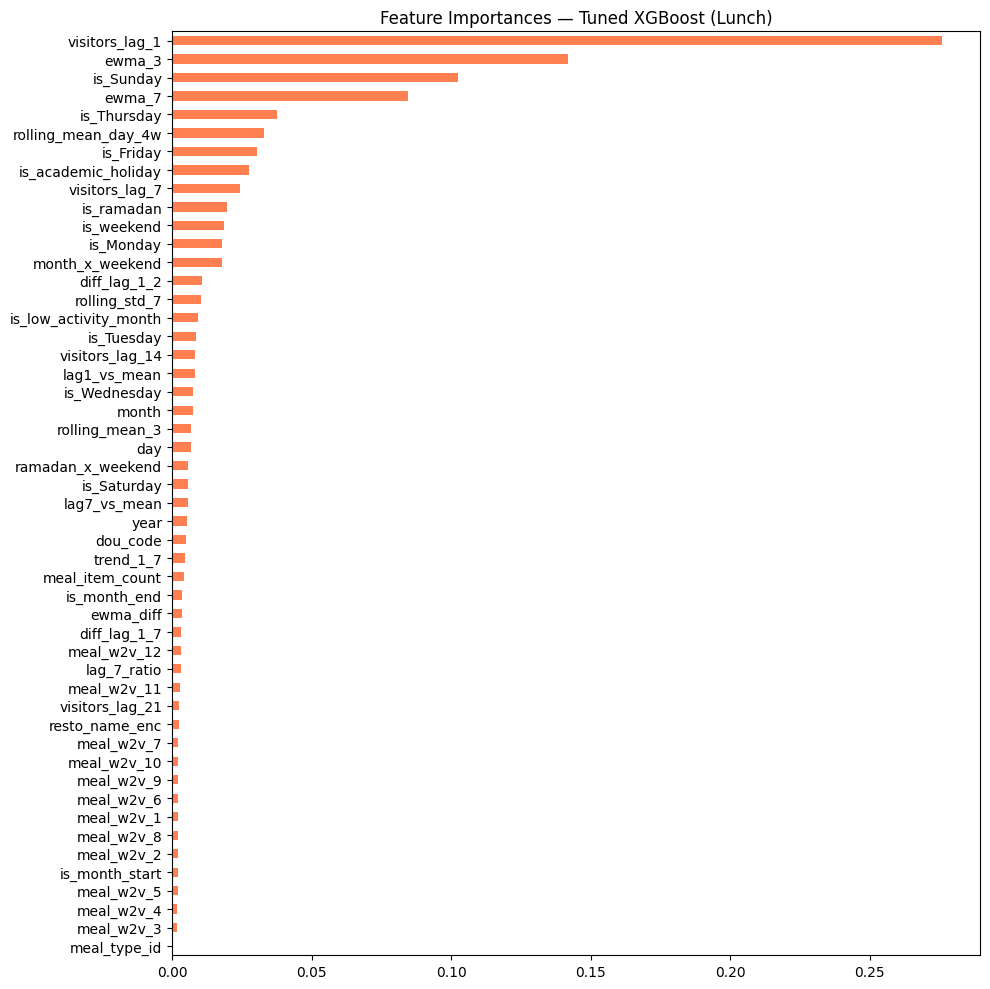

visitors_lag_1           0.275641
ewma_3                   0.141960
is_Sunday                0.102335
ewma_7                   0.084431
is_Thursday              0.037507
rolling_mean_day_4w      0.033056
is_Friday                0.030579
is_academic_holiday      0.027444
visitors_lag_7           0.024216
is_ramadan               0.019852
is_weekend               0.018641
is_Monday                0.017806
month_x_weekend          0.017804
diff_lag_1_2             0.010844
rolling_std_7            0.010377
is_low_activity_month    0.009186
is_Tuesday               0.008678
visitors_lag_14          0.008217
lag1_vs_mean             0.008140
is_Wednesday             0.007523
month                    0.007384
rolling_mean_3           0.006883
day                      0.006845
ramadan_x_weekend        0.005913
is_Saturday              0.005844
lag7_vs_mean             0.005646
year                     0.005405
dou_code                 0.004927
trend_1_7                0.004561
meal_item_coun

In [ ]:
imp = pd.Series(xgb_tuned.feature_importances_, index=X_train.columns)
imp.sort_values().plot(kind='barh', figsize=(10, 10), color='coral')
plt.title('Feature Importances — Tuned XGBoost (Lunch)')
plt.tight_layout(); plt.show()
print(imp.sort_values(ascending=False))

### Feature Importance Analysis (Lunch)

**1. The "Memory" Tier (~41% importance)**
- **`visitors_lag_1` (27.5%)** and **`ewma_3` (14.2%)**: Recent lunch attendance is the strongest predictor.

**2. The "Weekly Rhythm" (~14% importance)**
- **`is_Sunday` (10.2%)** and **`is_Thursday` (3.7%)**: Sunday peaks and Thursday drops (student exodus) are critical structural signals for lunch volume.

**3. Context Features**
- **`is_academic_holiday` (2.7%)** and **`is_ramadan` (1.9%)**: The model correctly weights these external events as secondary drivers compared to short-term momentum.

##  14 — Final Diagnosis

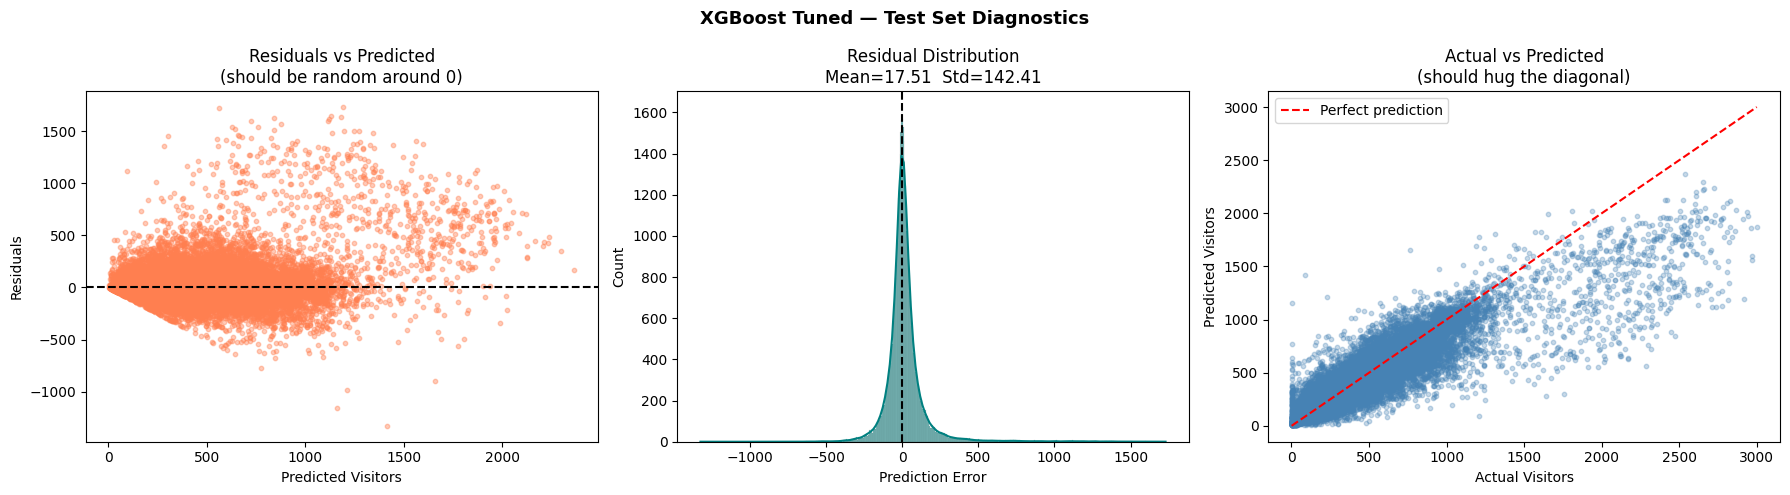

Mean residual        : 17.51
Std of residuals     : 142.41
Max over-prediction  : -1328
Max under-prediction : 1731
% within ±50 visitors: 57.8%
% within ±100 visitors: 79.4%


In [ ]:
y_real    = np.expm1(y_test)
y_pred    = np.expm1(xgb_tuned.predict(X_test))
residuals = y_real - y_pred

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Residuals vs Predicted ──
axes[0].scatter(y_pred, residuals, alpha=0.4, color='coral', s=10)
axes[0].axhline(0, color='black', linestyle='--')
axes[0].set_xlabel('Predicted Visitors')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Predicted\n(should be random around 0)')

# ── Residual Distribution ──
sns.histplot(residuals, kde=True, color='teal', ax=axes[1])
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_xlabel('Prediction Error')
axes[1].set_title(f'Residual Distribution\nMean={residuals.mean():.2f}  Std={residuals.std():.2f}')

# ── Actual vs Predicted ──
axes[2].scatter(y_real, y_pred, alpha=0.3, color='steelblue', s=10)
axes[2].plot([y_real.min(), y_real.max()],
             [y_real.min(), y_real.max()],
             color='red', linestyle='--', linewidth=1.5, label='Perfect prediction')
axes[2].set_xlabel('Actual Visitors')
axes[2].set_ylabel('Predicted Visitors')
axes[2].set_title('Actual vs Predicted\n(should hug the diagonal)')
axes[2].legend()

plt.suptitle('XGBoost Tuned — Test Set Diagnostics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Mean residual        : {residuals.mean():.2f}')
print(f'Std of residuals     : {residuals.std():.2f}')
print(f'Max over-prediction  : {residuals.min():.0f}')
print(f'Max under-prediction : {residuals.max():.0f}')
print(f'% within ±50 visitors: {(np.abs(residuals) <= 50).mean()*100:.1f}%')
print(f'% within ±100 visitors: {(np.abs(residuals) <= 100).mean()*100:.1f}%')